# Problem 2: The Solow model with a time-varying savings rate

All variables are per worker. Output is $y_t=k_t^\alpha$, a share $s_t$ of output is invested,
and capital accumulates as $k_{t+1}=s_tf(k_t)+(1-\delta)k_t$.

Welfare of a consumption path is $W=\sum_{t=0}^{T-1}\beta^t\log c_t$.

The model is implemented in `SolowModel.py`. The methods `s_path`, `welfare` and `evaluate`
are the ones written for this exam; the rest is from Lecture 9.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize

from SolowModel import SolowModelClass

plt.rcParams.update({'font.size':11,'figure.dpi':100,'axes.grid':True,'grid.alpha':0.3})

model = SolowModelClass()
par = model.par
print(model)

Solow model with:
  alpha = 0.3333 (capital share)
  delta = 0.3000 (depreciation rate)
  s_bar = 0.2500 (long-run savings rate)
  beta  = 0.8333 (discount factor)
  k0    = 0.1000 (initial capital per worker)
  T     = 100 (number of periods)


In [2]:
def store(sim):
    """ copy the simulated paths out of the model, so they are not overwritten
        by the next call to simulate """

    return dict(s=sim.s.copy(),k=sim.k.copy(),c=sim.c.copy(),y=sim.y.copy())

def plot_paths(paths,figsize=(14,4)):
    """ plot s_t, k_t and c_t against t in three panels

    Args:

        paths (dict): {label: dict of paths from store()}

    """

    fig,axes = plt.subplots(1,3,figsize=figsize)
    t = np.arange(par.T)

    for name,var,title in zip(['s','k','c'],axes,
        ['savings rate, $s_t$','capital, $k_t$','consumption, $c_t$']):

        for label,path in paths.items():
            ls = '--' if label == 'baseline' else '-'
            lw = 2.5 if label == 'baseline' else 1.5
            var.plot(t,path[name],ls,lw=lw,label=label,color='black' if label=='baseline' else None)

        var.set_title(title)
        var.set_xlabel('$t$')

    axes[0].legend(frameon=True,fontsize=9)
    fig.tight_layout()

    return fig,axes

## Question 1

### 1. Steady state for $s=\bar{s}$

In [3]:
# a. analytical steady state
k_ss,y_ss,c_ss = model.steady_state() # s = par.s_bar by default

# b. numerical steady state, the root of k_next(k,s)-k
k_ss_num = model.solve_steady_state()

print(f'analytical: k* = {k_ss:.6f}, y* = {y_ss:.6f}, c* = {c_ss:.6f}')
print(f'root-finder: k* = {k_ss_num:.6f}')
print(f'difference: {np.abs(k_ss-k_ss_num):.2e}')

assert np.isclose(k_ss,k_ss_num), 'the analytical and the numerical steady state disagree'

analytical: k* = 0.760726, y* = 0.912871, c* = 0.684653
root-finder: k* = 0.760726
difference: 0.00e+00


The two agree to machine precision, so the formula and the law of motion are consistent.

### 2. The baseline simulation

In [4]:
baseline = store(model.simulate(par.s_bar))

print(f'c_0     = {baseline["c"][0]:.6f}')
print(f'c_(T-1) = {baseline["c"][-1]:.6f}   (c* = {c_ss:.6f})')
print(f'k_(T-1) = {baseline["k"][-1]:.6f}   (k* = {k_ss:.6f})')

c_0     = 0.348119
c_(T-1) = 0.684653   (c* = 0.684653)
k_(T-1) = 0.760726   (k* = 0.760726)


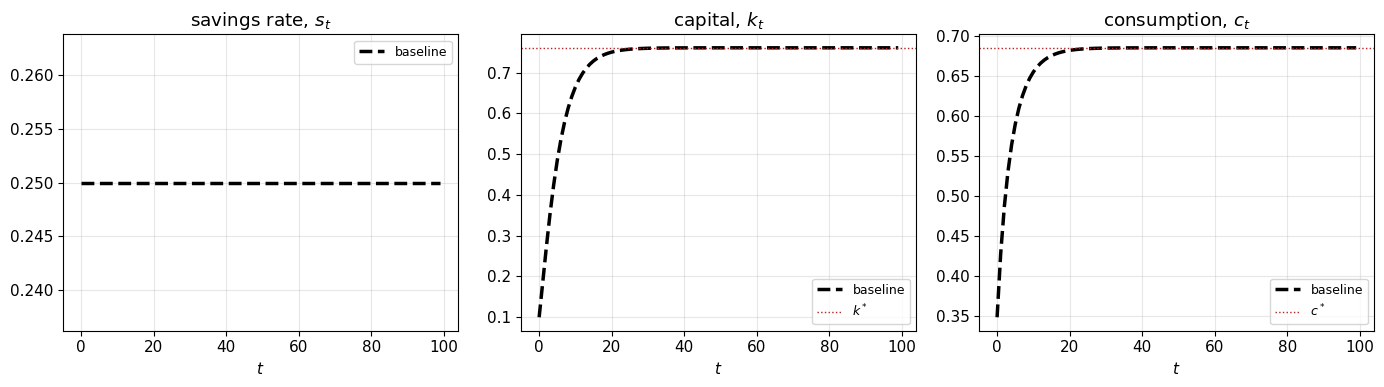

In [5]:
fig,axes = plot_paths({'baseline':baseline})
axes[1].axhline(k_ss,color='firebrick',lw=1,ls=':',label='$k^*$')
axes[2].axhline(c_ss,color='firebrick',lw=1,ls=':',label='$c^*$')
axes[1].legend(fontsize=9); axes[2].legend(fontsize=9)
plt.show()

Starting from $k_0=0.10$, far below $k^*$, capital rises quickly and then flattens out.
By $t=T-1$ the economy has been in the steady state for a long time: $k_{T-1}=k^*$ and
$c_{T-1}=c^*$ to six decimals.

### 3. Testing the simulator

Three cases where the answer is known in advance:

1. an economy starting in $k^*$ with $s_t=\bar{s}$ must stay in $k^*$ forever
2. with $s_t=0$ nothing is invested, so capital decays as $k_t=(1-\delta)^tk_0$
3. with $s_t=0$ all output is consumed, so $c_t=y_t=k_t^\alpha$

In [6]:
# test 1: the steady state is a fixed point
sim = model.simulate(par.s_bar,k0=k_ss)
assert np.allclose(sim.k,k_ss), 'an economy starting in k* must stay in k*'

# test 2: with s = 0 capital decays geometrically
sim = model.simulate(0.0)
k_analytical = (1-par.delta)**np.arange(par.T)*par.k0
assert np.allclose(sim.k,k_analytical), 'with s = 0 capital must decay as (1-delta)^t*k0'

# test 3: with s = 0 everything is consumed
assert np.allclose(sim.c,sim.y), 'with s = 0 consumption must equal output'

print('all tests passed')

all tests passed


## Question 2

The savings rule is
$$s_t=\bar{s}+(s_0-\bar{s})\varphi^t$$
implemented in `SolowModel.s_path()`. It is evaluated for the four combinations below.

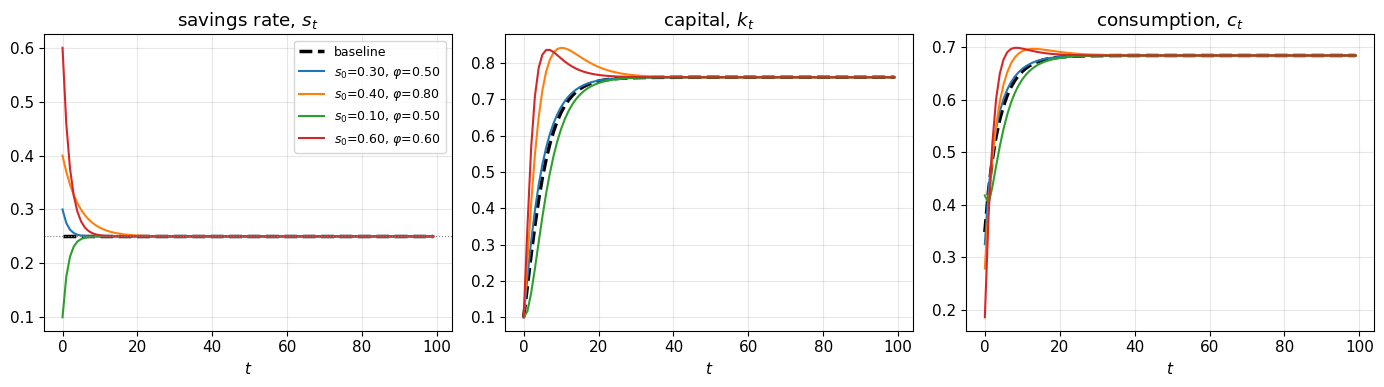

In [7]:
combos = [(0.30,0.50),(0.40,0.80),(0.10,0.50),(0.60,0.60)]

paths = {'baseline':baseline}
for s0,phi in combos:
    label = f'$s_0$={s0:.2f}, $\\varphi$={phi:.2f}'
    paths[label] = store(model.simulate(model.s_path(s0,phi)))

fig,axes = plot_paths(paths)
axes[0].axhline(par.s_bar,color='grey',lw=0.8,ls=':')
plt.show()

### 3. Capital in the last period

In [8]:
rows = [{'s0':np.nan,'phi':np.nan,'k_(T-1)':baseline['k'][-1],'s_(T-1)':baseline['s'][-1]}]
for s0,phi in combos:
    path = paths[f'$s_0$={s0:.2f}, $\\varphi$={phi:.2f}']
    rows.append({'s0':s0,'phi':phi,'k_(T-1)':path['k'][-1],'s_(T-1)':path['s'][-1]})

table = pd.DataFrame(rows,index=['baseline']+[f'({s0:.2f},{phi:.2f})' for s0,phi in combos])
display(table.style.format({'s0':'{:.2f}','phi':'{:.2f}','k_(T-1)':'{:.6f}','s_(T-1)':'{:.6f}'},na_rep='-'))

print(f'largest deviation from k* = {np.max([abs(r["k_(T-1)"]-k_ss) for r in rows]):.2e}')

,s0,phi,k_(T-1),s_(T-1)
baseline,-,-,0.760726,0.250000
"(0.30,0.50)",0.30,0.50,0.760726,0.250000
"(0.40,0.80)",0.40,0.80,0.760726,0.250000
"(0.10,0.50)",0.10,0.50,0.760726,0.250000
"(0.60,0.60)",0.60,0.60,0.760726,0.250000


largest deviation from k* = 4.07e-09


**Yes, they are all the same**, and equal to $k^*=0.760726$.

The reason is that $\varphi<1$, so $\varphi^t\to0$ and $s_t\to\bar{s}$ regardless of $s_0$.
Once the savings rate has settled at $\bar{s}$, capital converges to the steady state belonging
to $\bar{s}$, and with $T=100$ there is plenty of time for that to happen. $s_0$ and $\varphi$
therefore only change the *transition*, never the long-run level.

### 4. What $s_0$ and $\varphi$ do

**$s_0$ sets where the savings path starts**, and thereby the trade-off in the first periods.
A high $s_0$ (0.60) means little is consumed early but capital is built up fast, so $c_t$ starts
low and crosses the baseline after a few periods. A low $s_0$ (0.10) does the opposite: high
consumption in the first periods, but capital accumulates slowly, so consumption is below the
baseline for a long stretch afterwards.

**$\varphi$ sets how long the deviation lasts.** $\varphi^t$ is the share of the initial gap
$s_0-\bar{s}$ that is left in period $t$, so the half-life is $\log(0.5)/\log\varphi$: about 1
period for $\varphi=0.50$ and about 3 periods for $\varphi=0.80$. With $\varphi=0.80$ the
savings rate is still noticeably above $\bar{s}$ after 10 periods, which is why
$(0.40,0.80)$ keeps consumption below the baseline much longer than $(0.30,0.50)$ does, even
though its $s_0$ is only a little higher.

Note that the two parameters interact: what matters for capital is the *area* under
$s_t-\bar{s}$, which is $(s_0-\bar{s})/(1-\varphi)$.

## Question 3

Welfare is $W=\sum_{t=0}^{T-1}\beta^t\log c_t$, implemented in `SolowModel.welfare()`.

In [9]:
W_baseline = model.welfare(baseline['c'])

rows = [{'s0':np.nan,'phi':np.nan,'W':W_baseline,'W - W_baseline':0.0}]
for s0,phi in combos:
    W = model.evaluate(s0,phi)
    rows.append({'s0':s0,'phi':phi,'W':W,'W - W_baseline':W-W_baseline})

table = pd.DataFrame(rows,index=['baseline']+[f'({s0:.2f},{phi:.2f})' for s0,phi in combos])
display(table.style.format({'s0':'{:.2f}','phi':'{:.2f}','W':'{:.6f}','W - W_baseline':'{:+.6f}'},na_rep='-')
             .background_gradient(subset=['W'],cmap='RdYlGn'))

,s0,phi,W,W - W_baseline
baseline,-,-,-3.994388,+0.000000
"(0.30,0.50)",0.30,0.50,-3.985706,+0.008682
"(0.40,0.80)",0.40,0.80,-4.091413,-0.097025
"(0.10,0.50)",0.10,0.50,-4.146018,-0.151630
"(0.60,0.60)",0.60,0.60,-4.340653,-0.346265


### 3. Which combinations beat the baseline?

Only **$(s_0,\varphi)=(0.30,0.50)$**, and by a small margin ($+0.0087$). The other three are
worse, $(0.60,0.60)$ by a lot ($-0.3463$).

**Could this have been seen from the figure in Question 2 alone? No, not reliably.** The
consumption paths cross the baseline: every rule with $s_0>\bar{s}$ gives lower consumption
early and higher consumption later, and the figure does not tell you how the two are weighted.
That is exactly what $W$ does, and with $\beta=1/1.2$ the discounting is heavy — $\beta^{10}
\approx0.16$ and $\beta^{20}\approx0.03$ — so what happens in the first 10-15 periods
dominates the sum, while the differences the eye is drawn to later in the figure count for
almost nothing. On top of that $\log c_t$ is concave, so a given fall in consumption hurts
more when consumption is low, which is precisely when the extra saving takes place.

The figure does rule out one thing: $(0.10,0.50)$ has *both* lower consumption from around
$t=2$ onwards and only a brief gain before that, so it is a poor candidate. But separating
$(0.30,0.50)$ from $(0.40,0.80)$ by eye is not possible.

## Question 4

### 1. Grid search over $s_0\in[0,0.60]$ and $\varphi\in[0,0.95]$

In [10]:
s0_grid = np.linspace(0,0.60,121)
phi_grid = np.linspace(0,0.95,96)

W_grid = np.empty((s0_grid.size,phi_grid.size))
for i,s0 in enumerate(s0_grid):
    for j,phi in enumerate(phi_grid):
        W_grid[i,j] = model.evaluate(s0,phi)

# the best point on the grid
i_best,j_best = np.unravel_index(np.argmax(W_grid),W_grid.shape)
s0_grid_best,phi_grid_best = s0_grid[i_best],phi_grid[j_best]
W_grid_best = W_grid[i_best,j_best]

print(f'best on the grid: s0 = {s0_grid_best:.4f}, phi = {phi_grid_best:.4f}, W = {W_grid_best:.6f}')
print(f'                  W - W_baseline = {W_grid_best-W_baseline:+.6f}')

best on the grid: s0 = 0.3100, phi = 0.2300, W = -3.984306
                  W - W_baseline = +0.010082


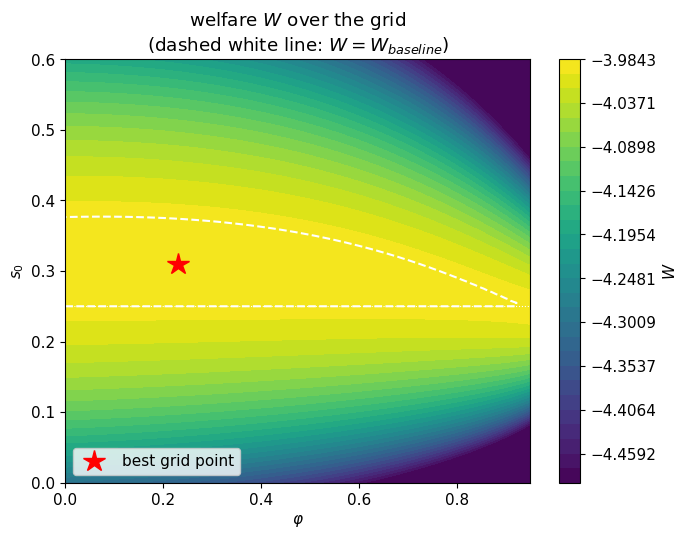

In [11]:
fig,ax = plt.subplots(figsize=(7.5,5.5))

# clip the color scale, otherwise the very bad corner (s0 = 0) dominates
levels = np.linspace(W_baseline-0.5,W_grid_best,30)
cs = ax.contourf(phi_grid,s0_grid,np.clip(W_grid,levels[0],None),levels=levels,cmap='viridis')
ax.contour(phi_grid,s0_grid,W_grid,levels=[W_baseline],colors='white',linewidths=1.5,linestyles='--')

ax.plot(phi_grid_best,s0_grid_best,'r*',ms=16,label='best grid point')
ax.axhline(par.s_bar,color='white',lw=0.8,ls=':')
ax.set_xlabel('$\\varphi$'); ax.set_ylabel('$s_0$')
ax.set_title('welfare $W$ over the grid\n(dashed white line: $W = W_{baseline}$)')
ax.legend(loc='lower left')
fig.colorbar(cs,ax=ax,label='$W$')
ax.grid(False)
plt.show()

### 2. Numerical optimization from the best grid point

In [12]:
obj = lambda x: -model.evaluate(x[0],x[1]) # minimize -W

result = optimize.minimize(obj,x0=[s0_grid_best,phi_grid_best],method='Nelder-Mead',
                           bounds=[(0,0.999),(0,0.999)],
                           options=dict(xatol=1e-10,fatol=1e-12,maxiter=10_000))

s0_opt,phi_opt = result.x
W_opt = -result.fun

print(f'grid:      s0 = {s0_grid_best:.6f}, phi = {phi_grid_best:.6f}, W = {W_grid_best:.8f}')
print(f'optimizer: s0 = {s0_opt:.6f}, phi = {phi_opt:.6f}, W = {W_opt:.8f}')
print(f'gain over the grid: {W_opt-W_grid_best:+.2e}')

grid:      s0 = 0.310000, phi = 0.230000, W = -3.98430600
optimizer: s0 = 0.311497, phi = 0.220770, W = -3.98430029
gain over the grid: +5.71e-06


The optimizer lands essentially on top of the best grid point. It only gains $6\cdot10^{-6}$
in $W$, which is what one should expect: the grid is fine enough ($0.005$ in $s_0$, $0.01$ in
$\varphi$) and $W$ is flat around the maximum. The value of the optimizer here is precision, not
a different answer — but it also confirms that the grid did not miss a better region.

### 3. The best rule against the baseline

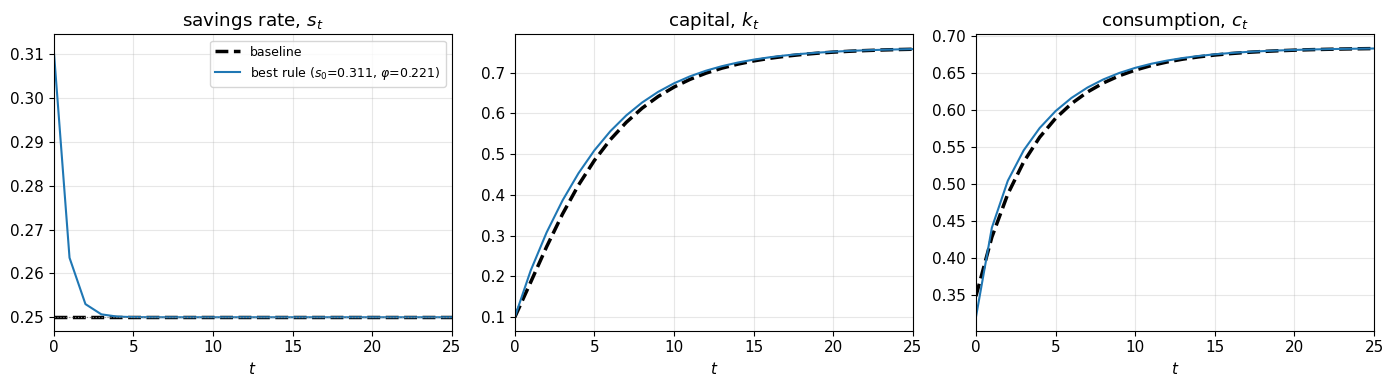

c_0 under the best rule = 0.319575
c_0 under the baseline  = 0.348119
difference              = -0.028544
first period with c_t > c_t^baseline: t = 1


In [13]:
best2 = store(model.simulate(model.s_path(s0_opt,phi_opt)))

fig,axes = plot_paths({'baseline':baseline,f'best rule ($s_0$={s0_opt:.3f}, $\\varphi$={phi_opt:.3f})':best2})
for ax in axes: ax.set_xlim(0,25) # zoom in on the transition, the paths coincide afterwards
axes[0].axhline(par.s_bar,color='grey',lw=0.8,ls=':')
plt.show()

# the first period in which consumption is above the baseline
above = np.where(best2['c'] > baseline['c'])[0]

print(f'c_0 under the best rule = {best2["c"][0]:.6f}')
print(f'c_0 under the baseline  = {baseline["c"][0]:.6f}')
print(f'difference              = {best2["c"][0]-baseline["c"][0]:+.6f}')
print(f'first period with c_t > c_t^baseline: t = {above[0]}')

The optimal rule saves *more* than the baseline at the start ($s_0=0.311$ against $0.25$)
and returns quickly ($\varphi=0.221$, a half-life of well under one period, so $s_t$ is
practically back at $\bar{s}$ by $t=3$).

Consumption is therefore sacrificed in period 0 only — $c_0$ falls by $0.029$ — and is above
the baseline from **$t=1$** onwards. This is the whole trade-off in a nutshell: with $k_0=0.10$
the marginal product of capital is $f'(k_0)=\frac{1}{3}k_0^{-2/3}\approx1.55$, so the gross
return on saving is $1.55+0.70=2.25$, far above $1/\beta=1.2$. Investing an extra unit early
pays off almost immediately. Once capital has grown the return falls, which is why the extra
saving should stop quickly, hence the low $\varphi$.

## Question 5

Now the long-run savings rate is a free parameter too:
$$s_t=s_\infty+(s_0-s_\infty)\varphi^t$$
`s_path` already takes `s_inf` as an optional third argument, so no new code is needed for the
rule itself. Several starting values are used, since a three-dimensional problem is easier to
get stuck in.

In [14]:
obj3 = lambda x: -model.evaluate(x[0],x[1],x[2]) # x = (s0,phi,s_inf)

x0s = [[s0_opt,phi_opt,par.s_bar],[0.60,0.50,0.20],[0.50,0.70,0.15],[0.30,0.30,0.20],[0.60,0.90,0.20]]

best_result = None
for x0 in x0s:
    res = optimize.minimize(obj3,x0=x0,method='Nelder-Mead',bounds=[(0,0.999)]*3,
                            options=dict(xatol=1e-10,fatol=1e-12,maxiter=20_000))
    print(f'  start {np.round(x0,2)} -> W = {-res.fun:.8f}')
    if best_result is None or res.fun < best_result.fun: best_result = res

s0_3,phi_3,sinf_3 = best_result.x
W_3 = -best_result.fun

print()
print(f's0 = {s0_3:.6f}, phi = {phi_3:.6f}, s_inf = {sinf_3:.6f}')
print(f'W  = {W_3:.6f}')
print(f'improvement on Question 4: {W_3-W_opt:+.6f}')

  start [0.31 0.22 0.25] -> W = -3.96696545
  start [0.6 0.5 0.2] -> W = -3.96696545
  start [0.5  0.7  0.15] -> W = -3.96696545
  start [0.3 0.3 0.2] -> W = -3.96696545


  start [0.6 0.9 0.2] -> W = -3.96696545

s0 = 0.313859, phi = 0.670774, s_inf = 0.198944
W  = -3.966965
improvement on Question 4: +0.017335


All starting values converge to the same point, so this looks like the global optimum.

The gain over Question 4 is $+0.0173$, ten times larger than what the two-parameter rule managed
to gain over the baseline ($+0.0100$). Freeing the long-run level matters more than fine-tuning
the transition.

### 2. Capital in the last period

In [15]:
best3 = store(model.simulate(model.s_path(s0_3,phi_3,sinf_3)))

k_ss_new = (sinf_3/par.delta)**(1/(1-par.alpha)) # steady state belonging to s_inf

# the modified golden rule: f'(k)+1-delta = 1/beta
k_mgr = (par.alpha*par.beta/(1-par.beta*(1-par.delta)))**(1/(1-par.alpha))
s_mgr = par.delta*k_mgr**(1-par.alpha)

print(f'k_(T-1) under the best three-parameter rule = {best3["k"][-1]:.6f}')
print(f'k* from Question 1 (s = s_bar = 0.25)       = {k_ss:.6f}')
print(f'steady state belonging to s_inf             = {k_ss_new:.6f}')
print()
print(f'modified golden rule: k = {k_mgr:.6f}, s = {s_mgr:.6f}')

k_(T-1) under the best three-parameter rule = 0.540025
k* from Question 1 (s = s_bar = 0.25)       = 0.760726
steady state belonging to s_inf             = 0.540025

modified golden rule: k = 0.544331, s = 0.200000


**No, they are not the same, and they should not be.**

$k_{T-1}=0.5400$ against $k^*=0.7607$, so the economy ends up with about 29% less capital.

The reason is that $\bar{s}=0.25$ was simply imposed; nothing said it was a good savings rate.
Once $s_\infty$ can be chosen, the optimizer picks $s_\infty=0.1989$, and capital settles at the
steady state belonging to *that* rate, $(s_\infty/\delta)^{1/(1-\alpha)}=0.5400$, which is what
$k_{T-1}$ equals.

And $0.199$ is not an arbitrary number. The savings rate that a discounted-utility maximizer
wants in the long run is the one satisfying the **modified golden rule**, where the net return on
capital equals the rate of time preference,
$$f'(k)+1-\delta=\frac{1}{\beta}\quad\Longrightarrow\quad
k_{mgr}=\left(\frac{\alpha\beta}{1-\beta(1-\delta)}\right)^{\frac{1}{1-\alpha}}=0.5443,
\qquad s_{mgr}=\delta k_{mgr}^{1-\alpha}=0.2000$$
The optimizer finds $0.1989$, essentially this value. It falls a hair short only because the
horizon is finite: with $T=100$ there is no reason to leave any capital behind at the end, so the
last periods are saved slightly less. Those periods carry weight $\beta^{100}\approx10^{-8}$,
which is why the effect is so small.

Saving $\bar{s}=0.25$ forever is thus *over*-accumulation relative to what the household would
choose: it builds capital whose return, $f'(k^*)+1-\delta=1.14$, is below $1/\beta=1.2$.

## Question 6

### 1. An alternative functional form

The rule in (6) forces the savings rate to move towards its long-run level *monotonically and at
a single speed*. A natural generalization is a **sum of two geometric terms**,
$$s_t=s_\infty+A\varphi_1^t+B\varphi_2^t,\qquad \varphi_1,\varphi_2\in[0,1)$$
with the five parameters $(s_\infty,A,\varphi_1,B,\varphi_2)$.

It satisfies the requirement in the question: both $\varphi_1^t$ and $\varphi_2^t$ go to zero,
so $s_t\to s_\infty$ and the economy still ends in the steady state belonging to $s_\infty$.
It also nests (6) exactly, as $B=0$ and $A=s_0-s_\infty$, so it cannot do worse than Question 5.
What it adds is a fast component and a slow component that can pull in opposite directions, which
allows a non-monotone path — a sharp initial burst of saving that dies out quickly on top of a
gentler drift towards $s_\infty$.

The savings rate is clipped to $[0,1]$, since nothing in the functional form guarantees it stays
there.

In [16]:
def s_path_mix(x):
    """ the alternative rule s_t = s_inf + A*phi1**t + B*phi2**t """

    s_inf,A,phi1,B,phi2 = x
    t = np.arange(par.T)

    return np.clip(s_inf + A*phi1**t + B*phi2**t,0.0,1.0)

obj6 = lambda x: -model.evaluate_path(s_path_mix(x))

x0s = [[sinf_3,s0_3-sinf_3,phi_3,0.0,0.5],  # the Question 5 solution, B = 0
       [0.20,0.40,0.90,-0.10,0.30],
       [0.20,0.30,0.60,0.10,0.95],
       [0.20,0.20,0.99,0.20,0.50]]

best6 = None
for x0 in x0s:
    res = optimize.minimize(obj6,x0=x0,method='Nelder-Mead',
                            options=dict(xatol=1e-11,fatol=1e-13,maxiter=60_000,maxfev=60_000))
    print(f'  start {np.round(x0,2)} -> W = {-res.fun:.8f}')
    if best6 is None or res.fun < best6.fun: best6 = res

W_6 = -best6.fun
s_6 = s_path_mix(best6.x)
mix6 = store(model.simulate(s_6))

names = ['s_inf','A','phi1','B','phi2']
print()
print(', '.join(f'{n} = {v:.6f}' for n,v in zip(names,best6.x)))
print(f'W = {W_6:.8f}')
print(f's_0 = {s_6[0]:.4f}, s_5 = {s_6[5]:.4f}, s_(T-1) = {s_6[-1]:.4f}, k_(T-1) = {mix6["k"][-1]:.6f}')

  start [0.2  0.11 0.67 0.   0.5 ] -> W = -3.96695135


  start [ 0.2  0.4  0.9 -0.1  0.3] -> W = -3.96695135
  start [0.2  0.3  0.6  0.1  0.95] -> W = -3.96696208


  start [0.2  0.2  0.99 0.2  0.5 ] -> W = -3.96696205

s_inf = 0.199990, A = 0.131840, phi1 = 0.632993, B = -0.018877, phi2 = 0.283983
W = -3.96695135
s_0 = 0.3130, s_5 = 0.2134, s_(T-1) = 0.2000, k_(T-1) = 0.544290


### How much is left to gain? An upper bound

Before comparing, it is worth knowing what the *best possible* savings path achieves. Since any
rule ultimately just produces a vector $(s_0,\dots,s_{T-1})$, $W$ can be maximized over all $T$
savings rates directly, with no functional form imposed at all. That is the full Ramsey problem
solved by brute force, and no parametric rule can beat it.

In [17]:
obj_free = lambda s_vec: -model.evaluate_path(np.clip(s_vec,1e-6,0.999))

res_free = optimize.minimize(obj_free,x0=s_6,method='L-BFGS-B',bounds=[(1e-6,0.999)]*par.T,
                             options=dict(maxiter=200_000,maxfun=200_000,ftol=1e-18,gtol=1e-16))

W_free = -res_free.fun
print(f'W with a completely free savings path = {W_free:.8f}')
print(f'the first ten savings rates: {np.round(res_free.x[:10],4)}')
print(f's_30 = {res_free.x[30]:.4f}, s_60 = {res_free.x[60]:.4f}  (modified golden rule: {s_mgr:.4f})')

W with a completely free savings path = -3.96695135
the first ten savings rates: [0.313  0.2781 0.2513 0.233  0.221  0.2134 0.2085 0.2053 0.2034 0.2021]
s_30 = 0.2000, s_60 = 0.2000  (modified golden rule: 0.2000)


### 3. Comparison

In [18]:
summary = pd.DataFrame([
    {'rule':'baseline, $s_t=\\bar{s}$','parameters':0,'W':W_baseline},
    {'rule':'Q4: $s_t=\\bar{s}+(s_0-\\bar{s})\\varphi^t$','parameters':2,'W':W_opt},
    {'rule':'Q5: $s_t=s_\\infty+(s_0-s_\\infty)\\varphi^t$','parameters':3,'W':W_3},
    {'rule':'Q6: $s_t=s_\\infty+A\\varphi_1^t+B\\varphi_2^t$','parameters':5,'W':W_6},
    {'rule':'upper bound: free $s_t$ each period','parameters':par.T,'W':W_free},
]).set_index('rule')

summary['W - W_baseline'] = summary['W']-W_baseline
summary['gap to the bound'] = W_free-summary['W']

display(summary.style.format({'W':'{:.6f}','W - W_baseline':'{:+.6f}','gap to the bound':'{:.2e}'}))

,parameters,W,W - W_baseline,gap to the bound
rule,,,,
"baseline, $s_t=\bar{s}$",0,-3.994388,+0.000000,2.74e-02
Q4: $s_t=\bar{s}+(s_0-\bar{s})\varphi^t$,2,-3.984300,+0.010087,1.73e-02
Q5: $s_t=s_\infty+(s_0-s_\infty)\varphi^t$,3,-3.966965,+0.027422,1.41e-05
Q6: $s_t=s_\infty+A\varphi_1^t+B\varphi_2^t$,5,-3.966951,+0.027436,6.35e-10
upper bound: free $s_t$ each period,100,-3.966951,+0.027436,0.00e+00


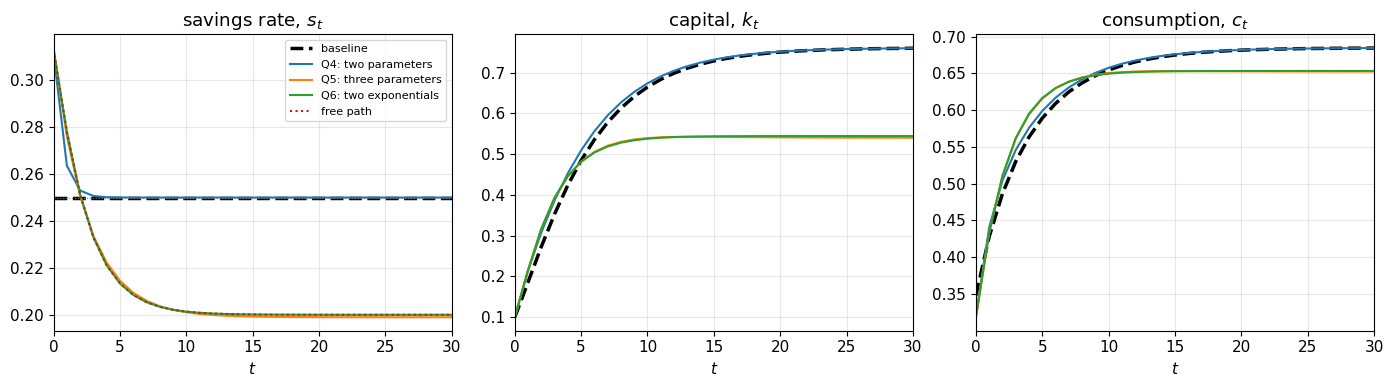

In [19]:
fig,axes = plot_paths({'baseline':baseline,
                       'Q4: two parameters':best2,
                       'Q5: three parameters':best3,
                       'Q6: two exponentials':mix6})
for ax in axes: ax.set_xlim(0,30)
axes[0].plot(np.arange(par.T),res_free.x,':',color='firebrick',lw=1.5,label='free path')
axes[0].axhline(par.s_bar,color='grey',lw=0.8,ls=':')
axes[0].legend(fontsize=8)
plt.show()

### Can it beat them?

**Yes, but only barely — and that is the interesting part of the answer.**

The five-parameter rule improves on Question 5 by about $1.4\cdot10^{-5}$ in $W$, against the
$+0.0173$ that Question 5 gained over Question 4. In practice the two paths are
indistinguishable.

The reason is visible in the last row of the table. The free path, which is the best that *any*
rule could ever do, reaches $W=-3.966951$, and the three-parameter rule of Question 5 is already
within $1.4\cdot10^{-5}$ of it. There was essentially nothing left to win. The extra flexibility
of the two-exponential rule is spent closing that last sliver of the gap, and the optimizer
duly sets $B\approx-0.019$, a small and fast-decaying correction on top of a path that was
already almost right.

This also explains *why* (6) works so well here. The free path in the left panel falls smoothly
and monotonically from $s_0\approx0.313$ to the modified golden rule $s_{mgr}=0.20$, with no
hump, no overshooting and no kink — a shape a single decaying exponential reproduces almost
perfectly. A richer functional form only pays off if the true optimum has a shape the simple
rule cannot make, and in this model it does not.

The lesson is that the binding constraint in Question 4 was never the shape of the rule but the
imposed long-run level $\bar{s}=0.25$. Once $s_\infty$ is free, one exponential is enough.